#K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a non-parametric algorithm, meaning it does not assume a specific functional form for the data (like a straight line). Instead, it hinges on the "birds of a feather" principle: similar data points exist in close proximity to one another.

For this KNN section, I will be using the Breast Cancer Wisconsin (Diagnostic) dataset.

It is a little more complex than the Iris dataset. It allows me to show that if you don't scale the data, the larger values (like area) will completely drown out the smaller ones (like smoothness), causing the algorithm to fail.


Core Implementation

We will implement the distance logic and prediction engine using the Euclidean distance metric:

$d(p,q)= \sqrt{(p-q)\cdot(p-q)}$


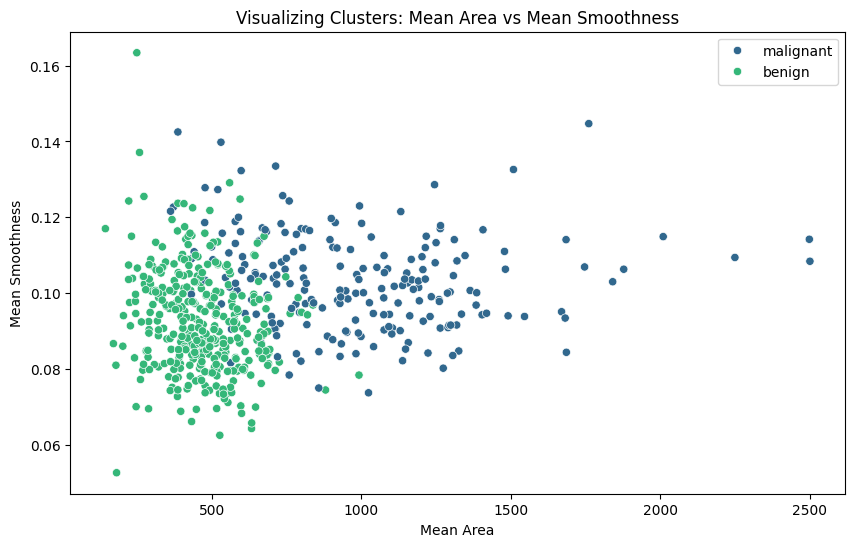

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_breast_cancer

# 1. Load Data
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Selecting features with different scales to demonstrate the need for scaling
X = df[['mean area', 'mean smoothness']].values
y = df['target'].values

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['mean area'], y=df['mean smoothness'], hue=data.target_names[df['target']], palette='viridis')
plt.title('Visualizing Clusters: Mean Area vs Mean Smoothness')
plt.xlabel('Mean Area')
plt.ylabel('Mean Smoothness')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Scaling (Essential for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Distance Function
def distance(p, q):
    return np.sqrt((p - q) @ (p - q))

# 4. KNN Algorithm
def k_nearest_neighbors(point, training_features, training_labels, k):
    neighbors = []
    for p, label in zip(training_features, training_labels):
        d = distance(point, p)
        neighbors.append([label, d])

    # Sort by distance (index 1)
    neighbors.sort(key=lambda x: x[1])
    return neighbors[:k]

def knn_predict(point, training_features, training_labels, k):
    neighbors = k_nearest_neighbors(point, training_features, training_labels, k)
    labels = [x[0] for x in neighbors]
    return max(labels, key=labels.count)

Finding the Optimal K:

As we increase K, our predictions become more stable due to majority voting. However, if K is too large, we begin to witness an increasing number of errors as the model becomes too "blunt".

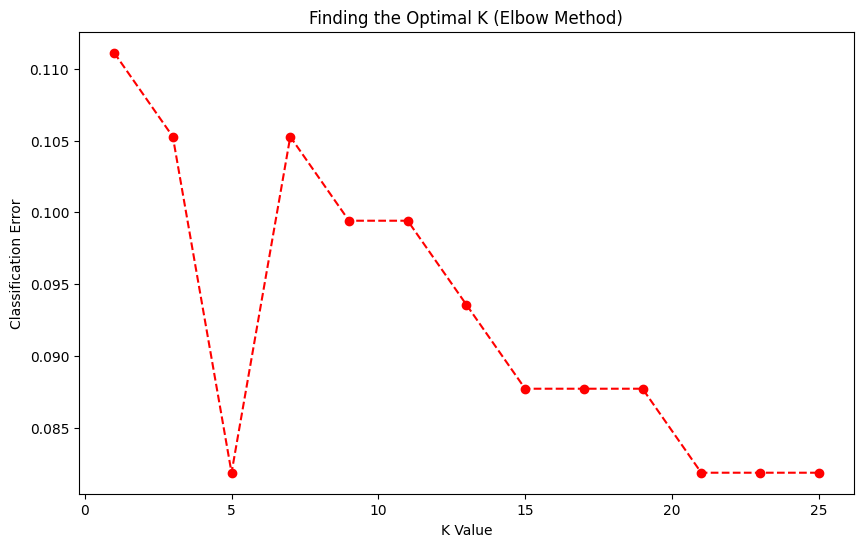

The best K value is 5


In [7]:

possible_k = [k for k in range(1, 26, 2)]
errors = []

for k in possible_k:
    predictions = [knn_predict(p, X_train_scaled, y_train, k) for p in X_test_scaled]
    errors.append(np.mean(predictions != y_test))

best_k = possible_k[np.argmin(errors)]

plt.figure(figsize=(10, 6))
plt.plot(possible_k, errors, color='red', marker='o', linestyle='dashed')
plt.title('Finding the Optimal K (Elbow Method)')
plt.xlabel('K Value')
plt.ylabel('Classification Error')
plt.show()

print(f"The best K value is {best_k}")



Evaluation and Feature Importance:

KNN does not have "coefficients" like Logistic Regression, so we evaluate its confusion matrix to see the types of errors it makes.

--- KNN Classification Report ---
              precision    recall  f1-score   support

   malignant       0.92      0.86      0.89        63
      benign       0.92      0.95      0.94       108

    accuracy                           0.92       171
   macro avg       0.92      0.91      0.91       171
weighted avg       0.92      0.92      0.92       171



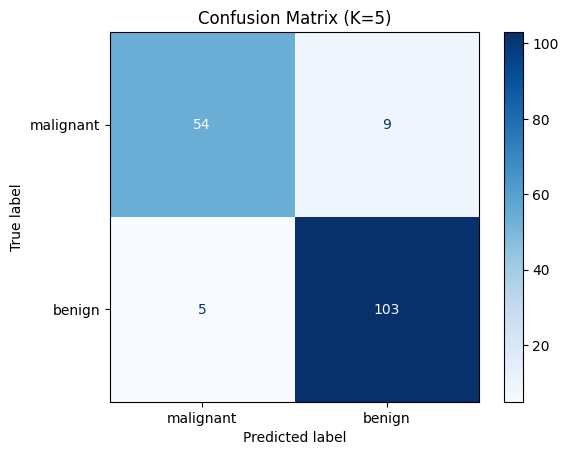

In [8]:
final_predictions = [knn_predict(p, X_train_scaled, y_train, best_k) for p in X_test_scaled]

print("--- KNN Classification Report ---")
print(classification_report(y_test, final_predictions, target_names=data.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (K={best_k})")
plt.show()

Following (the lecture/ colab) logic, KNN is essentially a search engine. If we treat a patient's cell measurements as a "query", we can find the most "similar" previous cases.

In [9]:
# REPLACE YOUR LAST BLOCK WITH THIS:
def find_similar_cases(patient_index, df, k=3):
    features = data.feature_names
    X_full = scaler.fit_transform(df[features])

    query_patient = X_full[patient_index]
    neighbors = k_nearest_neighbors(query_patient, X_full, df['target'].values, k+1)

    print(f"--- Similarity Search for Patient {patient_index} ---")
    print(f"Current Diagnosis: {data.target_names[df['target'].iloc[patient_index]]}")
    print(f"\nTop {k} most similar historical cases:")

    for i in range(1, k+1):
        # neighbors[i][0] is the label, [i][1] is the distance
        neighbor_label = data.target_names[neighbors[i][0]]
        dist = neighbors[i][1]
        print(f"{i}. Case Index {i}: Status: {neighbor_label} | Distance: {dist:.4f}")

find_similar_cases(10, df)

--- Similarity Search for Patient 10 ---
Current Diagnosis: malignant

Top 3 most similar historical cases:
1. Case Index 1: Status: malignant | Distance: 1.8699
2. Case Index 2: Status: malignant | Distance: 1.9310
3. Case Index 3: Status: malignant | Distance: 2.1188


### Findings
The model achieved an impressive overall accuracy of 0.92 using K=5. The error-rate plot indicated that K=5 was large enough to remain stable against noise, but small enough to capture the distinct clusters formed by the mean area and mean smoothness features.

Looking at the classification report and confusion matrix, we can observe the following:

Class Performance: The model is exceptionally strong at identifying benign cases.

Malignant Classification: The F1-score for malignant cases is 0.89. While slightly lower than the benign class, the precision of 0.92 indicates that when the model identifies a tumor as malignant, it is highly reliable.

Similarity: The similarity search for Patient 10 confirmed the algorithm's mechanical integrity; the three closest historical neighbors were all malignant, mirroring the patient's actual diagnosis and validating the "birds of a feather" assumption.

### Limitations

Feature Constraints: By using only two features (mean area and mean smoothness), the model may overlook subtle architectural features of the cells that could improve the 0.86 recall for malignant cases.

Clinical setting: In a medical context, a recall of 0.86 means some malignant cases were missed (False Negatives?). In future iterations, adding more features or adjusting the decision threshold might be necessary to prioritize patient safety.